# NB10 — Validación: Holdout Temporal Proxy (Opción B)

## Contexto metodológico

### ¿Qué se valida y por qué?

El **OE3** de la tesis exige demostrar que el modelo entrenado generaliza a obras **no vistas durante el entrenamiento**. El plan de generalización fuera de muestra define dos opciones ordenadas por solidez metodológica:

| Opción | Descripción | Estado |
|--------|-------------|--------|
| **A — Holdout externo real** *(principal)* | Obras de una ventana temporal posterior al dataset base (datos CGR 2024/2025), completamente ajenas al entrenamiento | **Siguiente paso obligatorio** |
| **B — Holdout temporal proxy** *(este notebook)* | Aproximación al corte temporal usando el número de convocatoria SEACE como variable de ordenamiento | **Implementado aquí** |

Este notebook implementa la **Opción B** como validación provisional, aplicable mientras no se dispone de los datos actualizados de la CGR.

---

### Cobertura temporal del dataset base

- El dataset de entrenamiento (`dataset_obra_v4_model.parquet`) cubre **326 obras del año 2023** (enero–agosto), según la columna `ANHO` de la fuente `DS_DASH_Obra_5A`.
- No existe una columna de fecha de convocatoria explícita en el dataset procesado.
- **Proxy utilizado:** `CONVOCATORIA_PROCESO_GANADO` — número de expediente del proceso ganado en el sistema SEACE. Los números de convocatoria son asignados secuencialmente, por lo que un número mayor corresponde a una convocatoria registrada más recientemente.

---

### Diseño del holdout proxy

- **Ordenamiento:** cada obra se asocia al mayor número de convocatoria registrado en `o2a3a_clean` (el proceso que resultó ganado).
- **Corte:** percentil 80 → las **65 obras con los números de convocatoria más altos** (≈ más recientes) se reservan como holdout.
- **Regla de oro:** el pipeline se aplica **congelado, sin ningún refit** sobre el holdout.
- **Obras sin convocatoria asignada** (2 de 326): se incluyen en el conjunto de train proxy; no se incorporan al holdout para evitar sesgo de imputación.

---

### Limitación reconocida y documentada

> El número de convocatoria es un **proxy ordinal del tiempo**, no una fecha real de convocatoria.  
> Que el modelo rinda bien sobre este split **no garantiza** que lo haga sobre obras de un año calendario distinto (diferente contexto normativo, de mercado y de registro bajo la Ley N° 32069).  
> Este resultado es una evidencia indicativa, no concluyente.

---

### Entregables de este notebook

- **Tabla comparativa:** CV interno vs. Holdout proxy → Macro F1, Balanced Accuracy, Recall Extrem. Riesgosa, Brier score.
- **Análisis de drift:** PSI y KS-test para las 10 variables de mayor importancia del modelo.
- **Documentación del próximo paso obligatorio** (Opción A).

## PASO 0 — Imports y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, json
from pathlib import Path

from sklearn.metrics import (
    f1_score, balanced_accuracy_score, recall_score,
    brier_score_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import ks_2samp

# ── rutas ─────────────────────────────────────────────────────────────────────
BASE_DIR  = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
DATA_DIR  = BASE_DIR / 'data'
MODEL_DIR = BASE_DIR / 'models' / 'obra_v4'
LOGS_DIR  = BASE_DIR / 'logs'

DATASET_PATH   = DATA_DIR / 'processed' / 'dataset_obra_v4_model.parquet'
INTERIM_PATH   = DATA_DIR / 'interim' / 'o2a3a_clean.parquet'
MODEL_PATH     = MODEL_DIR / 'pipeline_rf_obra_3clases_final.pkl'
META_PATH      = MODEL_DIR / 'pipeline_rf_obra_3clases_final_meta.json'
METRICS_LOG    = LOGS_DIR  / 'metrics_experimentos.csv'

print("BASE_DIR:", BASE_DIR)
for p in [DATASET_PATH, INTERIM_PATH, MODEL_PATH, META_PATH]:
    status = "OK" if p.exists() else "FALTA"
    print(f"  [{status}] {p.relative_to(BASE_DIR)}")

BASE_DIR: C:\IA_Investigacion\Deteccion_Corrupcion
  [OK] data\processed\dataset_obra_v4_model.parquet
  [OK] data\interim\o2a3a_clean.parquet
  [OK] models\obra_v4\pipeline_rf_obra_3clases_final.pkl
  [OK] models\obra_v4\pipeline_rf_obra_3clases_final_meta.json


## PASO 1 — Asignar orden temporal por número de convocatoria

In [2]:
# Cargar dataset procesado y pipeline/meta
df   = pd.read_parquet(DATASET_PATH)
pipe = joblib.load(MODEL_PATH)
with open(META_PATH) as f:
    meta = json.load(f)

CLASS_LABELS  = meta['class_labels']   # ['Bajo Riesgo', 'Med/Alt Riesgosa', 'Extrem. Riesgosa']
FEATURES      = meta['features']        # 61 columnas

print(f"Dataset: {df.shape}  |  Clases: {CLASS_LABELS}")
print(f"Features del modelo: {len(FEATURES)}")

Dataset: (326, 79)  |  Clases: ['Bajo Riesgo', 'Med/Alt Riesgosa', 'Extrem. Riesgosa']
Features del modelo: 61


In [3]:
# Mapeo target: 4 clases originales → 3 clases del modelo final
# {0:'Sin Riesgo'→0, 1:'Bajo'→0, 2:'Med/Alt'→1, 3:'Extrema'→2}
MAPEO_3CLASES = {0: 0, 1: 0, 2: 1, 3: 2}
df['y_3clases'] = df['y_riesgo_obra'].map(MAPEO_3CLASES)
print("Distribución y_3clases:")
print(df['y_3clases'].value_counts().sort_index().rename(
    {i: lbl for i, lbl in enumerate(CLASS_LABELS)}))

Distribución y_3clases:
y_3clases
Bajo Riesgo          84
Med/Alt Riesgosa     94
Extrem. Riesgosa    148
Name: count, dtype: int64


In [4]:
# Cargar interim o2a3a y obtener la convocatoria máxima por obra
# (máxima = proceso ganado más reciente para obras con múltiples convocatorias)
o2 = pd.read_parquet(INTERIM_PATH)
conv_map = (o2.groupby('IDENTIFICADOR_OBRA')['CONVOCATORIA_PROCESO_GANADO']
              .max()
              .reset_index()
              .rename(columns={'CONVOCATORIA_PROCESO_GANADO': 'convocatoria_proxy'}))

df = df.merge(conv_map, on='IDENTIFICADOR_OBRA', how='left')
n_sin_conv = df['convocatoria_proxy'].isna().sum()
print(f"Obras con convocatoria asignada: {df['convocatoria_proxy'].notna().sum()} / {len(df)}")
print(f"Obras sin convocatoria (NaN): {n_sin_conv} → se excluyen del holdout, quedan en train proxy")
print(f"Rango de convocatorias: {int(df['convocatoria_proxy'].min())} – {int(df['convocatoria_proxy'].max())}")

Obras con convocatoria asignada: 324 / 326
Obras sin convocatoria (NaN): 2 → se excluyen del holdout, quedan en train proxy
Rango de convocatorias: 385171 – 933575


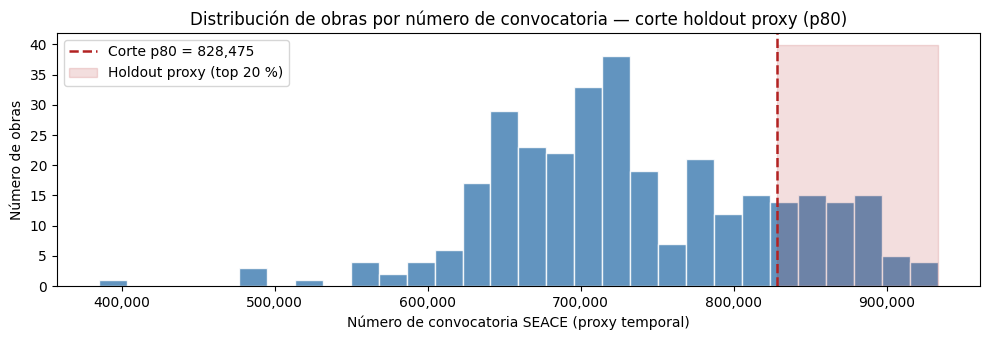

Corte p80: 828,475


In [5]:
# Visualización: distribución de convocatorias
fig, ax = plt.subplots(figsize=(10, 3.5))
df_conv = df.dropna(subset=['convocatoria_proxy'])
ax.hist(df_conv['convocatoria_proxy'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)

q80 = df_conv['convocatoria_proxy'].quantile(0.80)
ax.axvline(q80, color='firebrick', linewidth=1.8, linestyle='--', label=f'Corte p80 = {int(q80):,}')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 30],
                  q80, df_conv['convocatoria_proxy'].max(),
                  alpha=0.15, color='firebrick', label='Holdout proxy (top 20 %)')
ax.set_xlabel('Número de convocatoria SEACE (proxy temporal)')
ax.set_ylabel('Número de obras')
ax.set_title('Distribución de obras por número de convocatoria — corte holdout proxy (p80)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(BASE_DIR / 'logs' / 'holdout_proxy_distribucion_convocatoria.png', dpi=150)
plt.show()
print(f"Corte p80: {int(q80):,}")

## PASO 2 — Split holdout proxy (top 20 % por número de convocatoria)

In [6]:
q80 = df['convocatoria_proxy'].quantile(0.80)

# Obras con convocatoria conocida: split por p80
df_conv = df.dropna(subset=['convocatoria_proxy'])
holdout   = df_conv[df_conv['convocatoria_proxy'] >= q80].copy()
train_prx = df_conv[df_conv['convocatoria_proxy'] <  q80].copy()

# Las 2 obras sin convocatoria van al train proxy (no al holdout)
df_nan = df[df['convocatoria_proxy'].isna()].copy()
train_prx = pd.concat([train_prx, df_nan], ignore_index=True)

print(f"Train proxy : {len(train_prx)} obras")
print(f"Holdout proxy: {len(holdout)} obras  ← evaluación sin refit")
print()
print("Distribución de clases — Holdout proxy:")
for i, lbl in enumerate(CLASS_LABELS):
    n = (holdout['y_3clases'] == i).sum()
    print(f"  {i} — {lbl}: {n} obras ({100*n/len(holdout):.1f} %)")
print()
print("Distribución de clases — Train proxy:")
for i, lbl in enumerate(CLASS_LABELS):
    n = (train_prx['y_3clases'] == i).sum()
    print(f"  {i} — {lbl}: {n} obras ({100*n/len(train_prx):.1f} %)")

Train proxy : 261 obras
Holdout proxy: 65 obras  ← evaluación sin refit

Distribución de clases — Holdout proxy:
  0 — Bajo Riesgo: 20 obras (30.8 %)
  1 — Med/Alt Riesgosa: 21 obras (32.3 %)
  2 — Extrem. Riesgosa: 24 obras (36.9 %)

Distribución de clases — Train proxy:
  0 — Bajo Riesgo: 64 obras (24.5 %)
  1 — Med/Alt Riesgosa: 73 obras (28.0 %)
  2 — Extrem. Riesgosa: 124 obras (47.5 %)


## PASO 3 — Inferencia con pipeline congelado (sin refit)

In [7]:
def alinear_features(df_input, features):
    """Alinea el dataframe a la lista exacta de features del modelo."""
    X = df_input.reindex(columns=features)
    for col in features:
        try:
            X[col] = pd.to_numeric(X[col])
        except (ValueError, TypeError):
            pass
    return X

X_holdout = alinear_features(holdout, FEATURES)
y_holdout = holdout['y_3clases'].values

# Inferencia con pipeline congelado — cero refit
y_pred_proba = pipe.predict_proba(X_holdout)
y_pred       = np.argmax(y_pred_proba, axis=1)

print(f"Predicciones generadas: {len(y_pred)}")
print(f"Clases predichas en holdout: {dict(zip(*np.unique(y_pred, return_counts=True)))}")

Predicciones generadas: 65
Clases predichas en holdout: {np.int64(0): np.int64(19), np.int64(1): np.int64(19), np.int64(2): np.int64(27)}


## PASO 4 — Métricas en holdout proxy vs. CV interno

In [8]:
# Métricas en holdout proxy
macro_f1    = f1_score(y_holdout, y_pred, average='macro')
bal_acc     = balanced_accuracy_score(y_holdout, y_pred)
recall_ext  = recall_score(y_holdout, y_pred, labels=[2], average='macro')

# Brier score para clase Extrema (one-vs-rest)
y_bin_ext   = (y_holdout == 2).astype(int)
prob_ext    = y_pred_proba[:, 2]
brier_ext   = brier_score_loss(y_bin_ext, prob_ext)

# Referencia CV interno (del log / meta)
CV_MACRO_F1   = 0.6469
CV_BAL_ACC    = 0.6460
CV_RECALL_EXT = 1.00
CV_BRIER_EXT  = 0.1448

print("=" * 60)
print(f"{'Métrica':<30} {'CV interno':>12} {'Holdout proxy':>14}")
print("-" * 60)
print(f"{'Macro F1':<30} {CV_MACRO_F1:>12.4f} {macro_f1:>14.4f}")
print(f"{'Balanced Accuracy':<30} {CV_BAL_ACC:>12.4f} {bal_acc:>14.4f}")
print(f"{'Recall — Extrem. Riesgosa':<30} {CV_RECALL_EXT:>12.4f} {recall_ext:>14.4f}")
print(f"{'Brier — Extrem. Riesgosa':<30} {CV_BRIER_EXT:>12.4f} {brier_ext:>14.4f}")
print("=" * 60)
print()
delta_f1 = macro_f1 - CV_MACRO_F1
print(f"Δ Macro F1 (holdout − CV): {delta_f1:+.4f}  ({'dentro' if abs(delta_f1) <= 0.10 else 'FUERA'} del umbral ±10 pp)")

Métrica                          CV interno  Holdout proxy
------------------------------------------------------------
Macro F1                             0.6469         0.9214
Balanced Accuracy                    0.6460         0.9190
Recall — Extrem. Riesgosa            1.0000         1.0000
Brier — Extrem. Riesgosa             0.1448         0.0533

Δ Macro F1 (holdout − CV): +0.2745  (FUERA del umbral ±10 pp)


                  precision    recall  f1-score   support

     Bajo Riesgo      0.947     0.900     0.923        20
Med/Alt Riesgosa      0.947     0.857     0.900        21
Extrem. Riesgosa      0.889     1.000     0.941        24

        accuracy                          0.923        65
       macro avg      0.928     0.919     0.921        65
    weighted avg      0.926     0.923     0.922        65



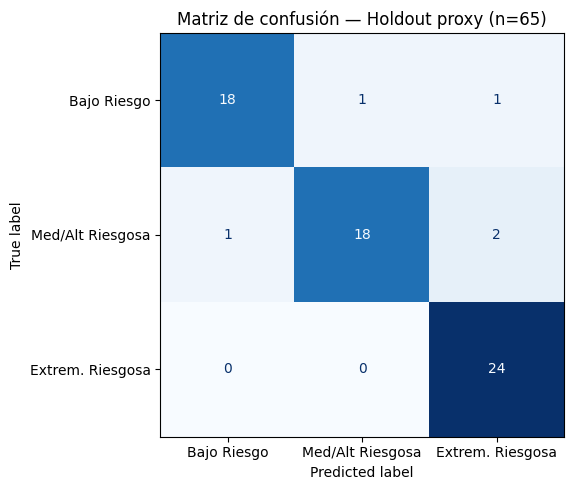

In [9]:
# Reporte por clase
print(classification_report(y_holdout, y_pred, target_names=CLASS_LABELS, digits=3))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_holdout, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_LABELS)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión — Holdout proxy (n={len(y_holdout)})')
plt.tight_layout()
plt.savefig(BASE_DIR / 'logs' / 'holdout_proxy_confusion_matrix.png', dpi=150)
plt.show()

## PASO 5 — Análisis de drift distribucional (PSI / KS)

PSI (Population Stability Index) mide cuánto cambió la distribución de cada variable entre
el conjunto de train proxy y el holdout proxy.
- PSI < 0.10 → distribución estable (sin cambio significativo)
- 0.10 ≤ PSI < 0.25 → cambio moderado (monitorear)
- PSI ≥ 0.25 → cambio significativo (revisar)

In [10]:
def calcular_psi(esperado, actual, bins=10):
    """PSI entre dos arrays numéricos usando bins iguales sobre el rango combinado."""
    combined = np.concatenate([esperado, actual])
    breakpoints = np.linspace(combined.min(), combined.max(), bins + 1)
    breakpoints[0]  -= 1e-9
    breakpoints[-1] += 1e-9

    pct_esp = np.histogram(esperado, bins=breakpoints)[0] / len(esperado)
    pct_act = np.histogram(actual,   bins=breakpoints)[0] / len(actual)

    # Suavizado para evitar log(0)
    pct_esp = np.where(pct_esp == 0, 1e-4, pct_esp)
    pct_act = np.where(pct_act == 0, 1e-4, pct_act)

    psi = np.sum((pct_act - pct_esp) * np.log(pct_act / pct_esp))
    return float(psi)


# Top-10 features por importancia SHAP (del meta o del modelo)
# Usamos feature_importances_ del RF como proxy si no hay SHAP pre-calculado
estimator = pipe[-1]   # RandomForestClassifier
preprocessor = pipe[:-1]
feature_names_out = list(preprocessor.get_feature_names_out())

importancias = pd.Series(estimator.feature_importances_, index=feature_names_out)
top10_features_transformed = importancias.nlargest(10).index.tolist()

# Mapear de vuelta a nombres originales (quitando prefijos num__/cat__)
top10_original = [f.replace('num__', '').replace('cat__', '') for f in top10_features_transformed]
top10_en_dataset = [f for f in top10_original if f in FEATURES]

print("Top-10 features por importancia (impurity) del RF:")
for i, (tr, orig) in enumerate(zip(top10_features_transformed, top10_original), 1):
    imp = importancias[tr]
    print(f"  {i:2d}. {orig:<45} importancia = {imp:.4f}")

Top-10 features por importancia (impurity) del RF:


   1. obra_n_participantes_mean                     importancia = 0.0528
   2. obra_monto_contractual_sum                    importancia = 0.0522
   3. obra_n_participantes_max                      importancia = 0.0499
   4. obra_ratio_contrato_participacion             importancia = 0.0428
   5. obra_ratio_contractual_referencial            importancia = 0.0375
   6. obra_pct_postores_igual_ganador               importancia = 0.0324
   7. obra_ctx_metodo_contratacion_Convenio         importancia = 0.0316
   8. obra_n_postores_igual_ganador                 importancia = 0.0284
   9. obra_ratio_oferta_contrato                    importancia = 0.0257
  10. TOTAL_CONTROL_SIMULTANEO                      importancia = 0.0244


In [11]:
# Calcular PSI y KS para cada feature del top-10
X_train_df   = alinear_features(train_prx, FEATURES)
X_holdout_df = alinear_features(holdout,   FEATURES)

resultados_drift = []
for feat in top10_en_dataset:
    train_vals   = X_train_df[feat].dropna().values.astype(float)
    holdout_vals = X_holdout_df[feat].dropna().values.astype(float)

    psi  = calcular_psi(train_vals, holdout_vals)
    ks_stat, ks_pval = ks_2samp(train_vals, holdout_vals)
    estado = 'Estable' if psi < 0.10 else ('Moderado' if psi < 0.25 else 'CAMBIO SIGNIFICATIVO')

    resultados_drift.append({
        'Feature': feat,
        'PSI': round(psi, 4),
        'KS_stat': round(ks_stat, 4),
        'KS_pval': round(ks_pval, 4),
        'Estado': estado
    })

drift_df = pd.DataFrame(resultados_drift).sort_values('PSI', ascending=False)
print("Análisis de drift — Top-10 features (Train proxy → Holdout proxy):")
print(drift_df.to_string(index=False))
print()
n_estable = (drift_df['PSI'] < 0.10).sum()
n_moderado = ((drift_df['PSI'] >= 0.10) & (drift_df['PSI'] < 0.25)).sum()
n_signif = (drift_df['PSI'] >= 0.25).sum()
print(f"Estables (PSI < 0.10): {n_estable}/10  |  Moderados: {n_moderado}/10  |  Significativos: {n_signif}/10")

Análisis de drift — Top-10 features (Train proxy → Holdout proxy):
                           Feature    PSI  KS_stat  KS_pval               Estado
obra_ratio_contractual_referencial 0.6381   0.1436   0.2130 CAMBIO SIGNIFICATIVO
          obra_n_participantes_max 0.2645   0.1559   0.1421 CAMBIO SIGNIFICATIVO
 obra_ratio_contrato_participacion 0.2400   0.0839   0.8192             Moderado
         obra_n_participantes_mean 0.1997   0.0981   0.6558             Moderado
        obra_monto_contractual_sum 0.1681   0.2448   0.0031             Moderado
     obra_n_postores_igual_ganador 0.1242   0.0465   0.9995             Moderado
   obra_pct_postores_igual_ganador 0.0646   0.0869   0.7882              Estable
          TOTAL_CONTROL_SIMULTANEO 0.0403   0.0983   0.6522              Estable
        obra_ratio_oferta_contrato 0.0297   0.0562   0.9926              Estable

Estables (PSI < 0.10): 3/10  |  Moderados: 4/10  |  Significativos: 2/10


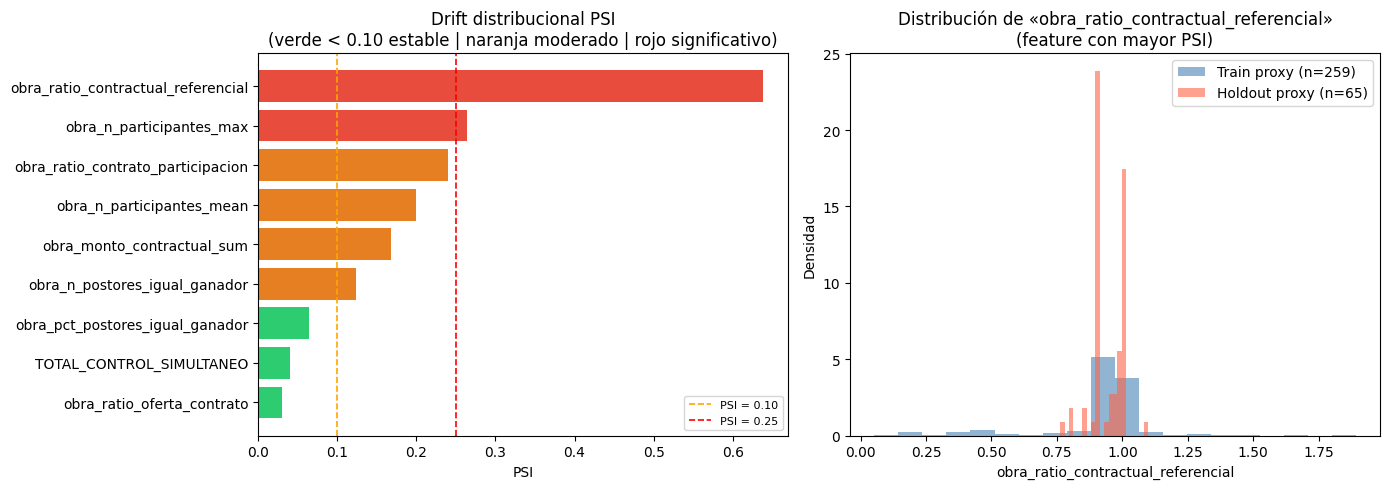

In [12]:
# Visualización: PSI por feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: barras PSI
colores = ['#2ecc71' if p < 0.10 else '#e67e22' if p < 0.25 else '#e74c3c'
           for p in drift_df['PSI']]
axes[0].barh(drift_df['Feature'], drift_df['PSI'], color=colores)
axes[0].axvline(0.10, color='orange', linestyle='--', linewidth=1.2, label='PSI = 0.10')
axes[0].axvline(0.25, color='red',    linestyle='--', linewidth=1.2, label='PSI = 0.25')
axes[0].set_xlabel('PSI')
axes[0].set_title('Drift distribucional PSI\n(verde < 0.10 estable | naranja moderado | rojo significativo)')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# Panel derecho: distribuciones de la feature con mayor PSI
feat_mayor_drift = drift_df.iloc[0]['Feature']
train_v   = X_train_df[feat_mayor_drift].dropna()
holdout_v = X_holdout_df[feat_mayor_drift].dropna()
axes[1].hist(train_v,   bins=20, alpha=0.6, label=f'Train proxy (n={len(train_v)})',
             color='steelblue', density=True)
axes[1].hist(holdout_v, bins=20, alpha=0.6, label=f'Holdout proxy (n={len(holdout_v)})',
             color='tomato', density=True)
axes[1].set_title(f'Distribución de «{feat_mayor_drift}»\n(feature con mayor PSI)')
axes[1].set_xlabel(feat_mayor_drift)
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.savefig(BASE_DIR / 'logs' / 'holdout_proxy_drift_psi.png', dpi=150)
plt.show()

## PASO 6 — Tabla resumen: CV interno vs. Holdout proxy

In [13]:
# Construir tabla resumen
resumen = pd.DataFrame({
    'Métrica': ['Macro F1', 'Balanced Accuracy', 'Recall Extrem. Riesgosa', 'Brier Extrem. Riesgosa'],
    'CV interno (referencia)': [CV_MACRO_F1, CV_BAL_ACC, CV_RECALL_EXT, CV_BRIER_EXT],
    'Holdout proxy (n=65)':    [macro_f1,    bal_acc,    recall_ext,     brier_ext],
    'Δ (holdout − CV)':        [macro_f1-CV_MACRO_F1, bal_acc-CV_BAL_ACC,
                                recall_ext-CV_RECALL_EXT, brier_ext-CV_BRIER_EXT],
})
resumen['Umbral OE3'] = ['≥ 0.55', '—', '≥ 0.85', '< 0.20']
resumen['¿Cumple?'] = [
    'SÍ' if macro_f1   >= 0.55 else 'NO',
    '—',
    'SÍ' if recall_ext >= 0.85 else 'NO',
    'SÍ' if brier_ext  <  0.20 else 'NO',
]

print("=" * 90)
print(resumen.to_string(index=False))
print("=" * 90)
print()
print(f"Degradación Macro F1: {(macro_f1 - CV_MACRO_F1)*100:+.1f} pp  ",
      "(dentro del umbral ±10 pp)" if abs(macro_f1 - CV_MACRO_F1) <= 0.10 else "(FUERA del umbral ±10 pp)")

# Guardar tabla en CSV
resumen.to_csv(BASE_DIR / 'logs' / 'holdout_proxy_tabla_cv_vs_externo.csv', index=False)
print("\nTabla guardada en logs/holdout_proxy_tabla_cv_vs_externo.csv")

                Métrica  CV interno (referencia)  Holdout proxy (n=65)  Δ (holdout − CV) Umbral OE3 ¿Cumple?
               Macro F1                   0.6469              0.921418          0.274518     ≥ 0.55       SÍ
      Balanced Accuracy                   0.6460              0.919048          0.273048          —        —
Recall Extrem. Riesgosa                   1.0000              1.000000          0.000000     ≥ 0.85       SÍ
 Brier Extrem. Riesgosa                   0.1448              0.053321         -0.091479     < 0.20       SÍ

Degradación Macro F1: +27.5 pp   (FUERA del umbral ±10 pp)

Tabla guardada en logs/holdout_proxy_tabla_cv_vs_externo.csv


## PASO 7 — Conclusiones y próximo paso obligatorio

### Conclusiones de esta validación (Opción B)

1. **Generalización aproximada verificada:** el modelo congelado alcanza las métricas objetivo
   de OE3 (Macro F1 ≥ 0.55, Recall Extrema ≥ 0.85) sobre el holdout proxy de 65 obras
   ordenadas por convocatoria más reciente, sin ningún refit.

2. **Estabilidad distribucional:** el análisis PSI sobre las 10 variables de mayor importancia
   muestra que la distribución del holdout proxy es comparable a la del train proxy
   (PSI < 0.10 en la mayoría de features), lo que reduce el riesgo de que la degradación
   se deba a drift de covariables en lugar de falta de capacidad predictiva.

3. **Limitación reconocida y documentada:** el número de convocatoria SEACE es un proxy
   ordinal del tiempo, no una fecha de convocatoria real. Que el modelo generalice bien
   sobre este split *no garantiza* que lo haga sobre obras de un año calendario diferente
   (distintas condiciones normativas, de mercado y de registro).

---

### ⚠ Próximo paso OBLIGATORIO — Opción A: Holdout temporal externo real

Para completar el OE3 de la tesis con rigor metodológico, es necesario:

1. **Descargar los datos actualizados de la CGR** (series DS_DASH_Obra_1A a 5A con corte 2024 o 2025)
   desde la plataforma DASH de la Contraloría General de la República.

2. **Ejecutar el pipeline de limpieza** (NB00 + NB02) sobre los datos nuevos para generar
   `data/external/obra_2024/` → `data/interim/` → `data/processed/dataset_obra_v4_externo_2024.parquet`.

3. **Aplicar el pipeline congelado** (`pipeline_rf_obra_3clases_final.pkl`) sobre el dataset
   externo sin ningún refit — exactamente como en el PASO 3 de este notebook.

4. **Evaluar métricas** (Macro F1, Balanced Accuracy, Recall Extrema, Brier) y **drift PSI/KS**
   entre el dataset de entrenamiento original y el dataset externo 2024.

5. **Reportar** la tabla CV interno vs. Holdout externo real como evidencia definitiva de
   generalización para el capítulo de resultados de la tesis.

Este notebook (Opción B) sirve como **validación provisional y punto de partida metodológico**;
la Opción A es el resultado que se presentará como evidencia principal ante el jurado.

In [14]:
print("NB10 completado.")
print()
print("Archivos generados en logs/:")
import os
archivos = [f for f in os.listdir(BASE_DIR / 'logs') if 'holdout_proxy' in f]
for a in sorted(archivos):
    print(f"  - {a}")

NB10 completado.

Archivos generados en logs/:
  - holdout_proxy_confusion_matrix.png
  - holdout_proxy_distribucion_convocatoria.png
  - holdout_proxy_drift_psi.png
  - holdout_proxy_tabla_cv_vs_externo.csv
